In [2]:
import numpy as np
import pandas as pd
import os as os

In [3]:
#現在のディレクトリ(Current Directory)の確認
os.getcwd()

'/Users/imaihiroshi/Documents/WORK/Programing/Python/narative_experiment/Jupyter'

In [20]:
#2つのファイルの読み込み
df_all = pd.read_csv('../data/csv/Data_20251014.csv')
df_NonWire = pd.read_csv('../data/csv/DataData_NonWire_20251015_Rep付.csv')

In [27]:
# 5つの列を抽出
df_NW = df_NonWire[['品番','cluster','medoid_score','tsne_x','tsne_y']]

In [28]:
#2つのデータフレームのマージ
df_merge = pd.merge(df_all,df_NW,how='left',on='品番')

In [43]:
#変数名の変更
df_merge = df_merge.rename(columns={
    'cluster_x':'cluster_ALL',
    'medoid_score_x':'medoid_score_ALL',
    'tsne_x_x':'tsne_x_ALL',
    'tsne_y_x':'tsne_y_ALL',
})

In [47]:
# 変数 cluster_y がNaNの為に動小数点になってしまったので戻す。
df_merge['cluster_y'] = df_merge['cluster_y'].astype("Int64")

## 🍀ランクと売上規模のデータの分析

In [8]:
# --------
# データファイルの読み込み
df = pd.read_csv('../data/csv/Data_20251020-NonWire_with_Rank.csv')

In [10]:
# %% クロス集計表を作成する
cate_A = sorted(df['商品ランク'].dropna().unique())
cate_B = sorted(df['売上規模'].dropna().unique())
df['商品ランク']=df['商品ランク'].astype(
    pd.CategoricalDtype(categories=cate_A,ordered=True)
)
df['売上規模']=df['売上規模'].astype(
    pd.CategoricalDtype(categories=cate_B,ordered=True)
)

pd.crosstab(df['商品ランク'],df['売上規模'],dropna=False)

売上規模,◎,〇
商品ランク,,
A,7,6
B,0,0
C,0,0


「商品ランク」と「売上規模」のクロス集計表が以下。  
これを見ると、商品ランクAの中に売上規模で◎と○が存在している。  
つまり、ある程度の売上規模のものは全て商品ランクがAという事になっている。
|  | ◎ | ○ |
|---|---|---|
| A | 7 | 6 |
| B | 0 | 0 |
| C | 0 | 0 |

### 🐳欠損にならないように、０を補完したデータファイルを作成しなおす

In [3]:
# --------
# データファイルの読み込み
df = pd.read_csv('../data/csv/Data_20251024-NonWire_with_Rank.csv')

In [ ]:
# 元のファイルに欠損がないと以下のように意図通りのクロス集計表になる。
pd.crosstab(df['商品ランク'],df['売上規模'],dropna=False)

売上規模,◎,〇,ー
商品ランク,,,
A,7,6,17
B,0,0,32
C,0,0,24


In [6]:
pd.crosstab(df['cluster'],df['商品ランク'],dropna=False)

商品ランク,A,B,C
cluster,,,
0,0,2,10
1,7,3,3
2,11,0,0
3,0,6,4
4,7,1,2
5,0,5,3
6,3,1,0
7,0,5,0
8,2,6,0


In [7]:
pd.crosstab(df['cluster'],df['売上規模'],dropna=False)

売上規模,◎,〇,ー
cluster,,,
0,0,0,12
1,2,1,10
2,1,1,9
3,0,0,10
4,2,2,6
5,0,0,8
6,0,2,2
7,0,0,5
8,2,0,6


In [15]:
# ==============================================================================
# ファイルを読み込んでのJSONファイル変換（独立して動作可能）
# ==============================================================================
import pandas as pd
import json

# ===============================================================
# （1）保存しておいた df ファイルの読み込み
# ===============================================================
# 例：CSVファイル名をここで指定
input_file = "../data/csv/Data_20251024-NonWire_with_Rank.csv"   # 必要に応じて変更
df_result = pd.read_csv(input_file, encoding="utf-8")

# ===============================================================
# JSON書き出し関数
# ===============================================================
def export_medoid_json(df_result, output_path="./data/df_medoid.json"):
    """
    df_resultをもとにJSONファイルを出力する
    - Rep列が存在する場合、その値が1ならRep=1、その他は0として書き出す
    """
    nodes = []

    rep_value = 0   #テンポラリー修正で強制的に０とする
    for idx, row in df_result.iterrows():
        # Rep列が存在し、値が1の場合は1、それ以外は0
        #rep_value = int(row["Rep"]) if "Rep" in df_result.columns and row["Rep"] == 1 else 0

        node = {
            "id": str(row["売上規模"]),     #テンポラリー修正　売上ランクを出す
            "icon": f"images/{row['品番']}.jpg",
            "x": float(2000 * row["tsne_x"]),
            "y": float(1480 * -row["tsne_y"]),
            "Rep": rep_value,
            "cluster": int(row["cluster"])
        }
        nodes.append(node)

    data = {
        "nodes": nodes,
        "links": []  # 今回はリンクなし
    }

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    rep_count = sum(1 for n in nodes if n["Rep"] == 1)
    print(f"✅ JSON書き出し完了: {len(nodes)} 件（代表点 {rep_count} 件）")
    print(f"保存先: {output_path}")

# ===============================================================
# 実行例
# ===============================================================
export_medoid_json(df_result, "../data/Data_20251024-NonWire_with_Rank.json")

✅ JSON書き出し完了: 86 件（代表点 0 件）
保存先: ../data/Data_20251024-NonWire_with_Rank.json


       ファイル  総段落数  意外性段落数  ポジティブ段落数  意外性割合  ポジティブ割合
0  MG125201    16       0         8  0.000    0.500
1  ME124302    14       2         8  0.143    0.571
2  ME518306    28       3        19  0.107    0.679
3  ME125302     3       1         2  0.333    0.667
4  ME524302     8       1         3  0.125    0.375


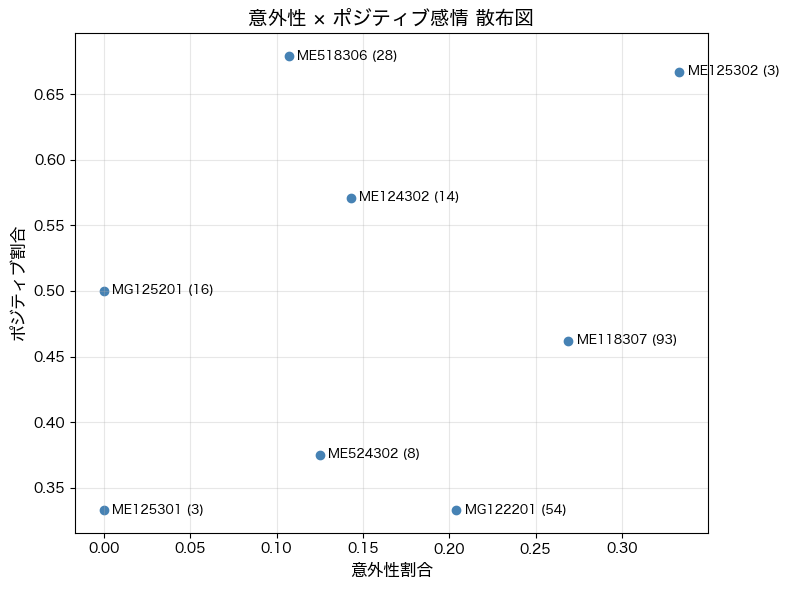

💾 図を保存しました: surprise_positive_scatter.png


In [4]:
# ==========================================
# surprise_positive_summary.csv → 散布図Plot
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt

# 日本語フォント設定（Macの場合）
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False  # マイナス記号を正しく表示

# ファイル読み込み
csv_path = "../data/reviews/surprise_positive_summary.csv"  # 同じフォルダにある場合
df = pd.read_csv(csv_path)

# データの確認
print(df.head())

# 散布図を描画
plt.figure(figsize=(8, 6))
plt.scatter(df["意外性割合"], df["ポジティブ割合"], color='steelblue')

# 各点に「品番名（総段落数）」を表示
for i, row in df.iterrows():
    label = f"{row['ファイル']} ({row['総段落数']})"
    plt.text(row["意外性割合"] + 0.005, row["ポジティブ割合"], label,
             fontsize=9, ha="left", va="center")

# 軸ラベル・タイトル
plt.xlabel("意外性割合", fontsize=12)
plt.ylabel("ポジティブ割合", fontsize=12)
plt.title("意外性 × ポジティブ感情 散布図", fontsize=14)

# グリッド・レイアウト調整
plt.grid(alpha=0.3)
plt.tight_layout()

# 保存と表示
plt.savefig("surprise_positive_scatter.png", dpi=300)
plt.show()

print("💾 図を保存しました: surprise_positive_scatter.png")

In [24]:
# ==========================================
# ブランド別 上代レンジプロット
# Data_20251024-NonWire_with_Rank.csv
# ==========================================
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


# 日本語フォント設定（Macの場合）
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False

# ファイル読み込み
csv_path = "../data/csv/Data_20251024-NonWire_with_Rank.csv"
df = pd.read_csv(csv_path, encoding="utf-8")

# 上代を数値化（万が一文字列が混じっていても安全に処理）
# df["上代"] = pd.to_numeric(df["上代"], errors="coerce")
df["上代"] = df["上代"].astype(str).str.replace(",", "").astype(float)
df["売上規模"] = df["売上規模"].astype(str).replace({"○": "〇"})

# ブランドごとにグループ化
brands = df["ブランド名"].unique()
brands_sorted = sorted(brands)

# 図の準備
plt.figure(figsize=(10, 6))

# ブランドごとの処理
for i, brand in enumerate(brands):
    subset = df[df["ブランド名"] == brand]
    if subset.empty:
        continue

    # 上代レンジの縦線
    min_price = subset["上代"].min()
    max_price = subset["上代"].max()
    plt.plot([i, i], [min_price, max_price], color="gray", linewidth=2)

    # ◎・○をプロット＋横線
    for _, row in subset.iterrows():
        scale = str(row["売上規模"]).strip()
        y = row["上代"]

        if scale in ["◎"]:
            plt.scatter(i, y, color="red", s=120, marker="o", zorder=3)
            #plt.hlines(y, i - 0.2, i + 0.2, colors="red", linestyles="--", linewidth=1.5)
            #print(f"◎ {brand}: {y}")

        elif scale in ["○", "〇"]:  # 両方対応！
            plt.scatter(i, y, color="orange", s=90, marker="o", zorder=3)
            #plt.hlines(y, i - 0.2, i + 0.2, colors="orange", linestyles="--", linewidth=1.2)
            #print(f"○ {brand}: {y}")


# 軸設定
plt.xticks(range(len(brands_sorted)), brands_sorted, rotation=45, ha="right")
plt.ylabel("上代（円）", fontsize=12)
plt.title("ブランド別 上代レンジと売上規模マーカー", fontsize=14)
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("brand_price_range_plot.pdf")
plt.show()

print("💾 図を保存しました: brand_price_range_plot.pdf")

/var/folders/wd/qvxl37td1wg7gsc7z6cn03t80000gn/T/ipykernel_41204/3187318512.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


UnicodeEncodeError: 'ascii' codec can't encode characters in position 3-13: ordinal not in range(128)

In [12]:
print(df["売上規模"].unique())
print(df["売上規模"].value_counts())

['.' '◎' '〇']
売上規模
.    73
◎     7
〇     6
Name: count, dtype: int64


In [14]:
print(df["ブランド名"].unique())

['FIT' 'NY' 'PEACE' 'Me' 'MAGIC' 'Yukine. Inc.']
